In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
def emnist_transform(img):
    img = transforms.functional.rotate(img, -90)
    img = transforms.functional.hflip(img)
    return img


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(emnist_transform),
    transforms.Normalize((0.5,), (0.5,))
])


train_dataset = datasets.EMNIST(root='./data', split='balanced', train=True, download=True, transform=transform)
test_dataset = datasets.EMNIST(root='./data', split='balanced', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


num_classes = 47
print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples: {len(test_dataset)}")

100%|██████████| 562M/562M [00:02<00:00, 264MB/s]


Training samples: 112800
Testing samples: 18800


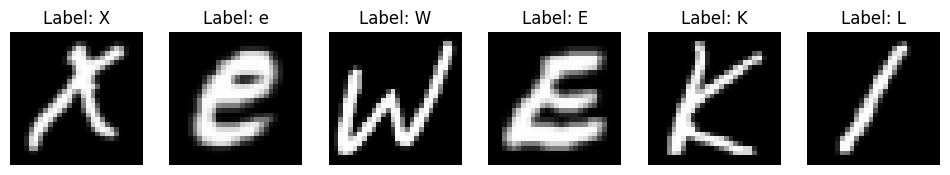

In [3]:
emnist_mapping = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabdefghnqrt"

dataiter = iter(train_loader)
images, labels = next(dataiter)

fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for i in range(6):
    img = images[i].numpy().squeeze()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {emnist_mapping[labels[i].item()]}")
    axes[i].axis('off')
plt.show()

In [4]:
class OCR_CNN(nn.Module):
    def __init__(self, num_classes):
        super(OCR_CNN, self).__init__()
        
        
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout(0.25)
        
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 7 * 7, 256) 
        self.relu3 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.dropout1(self.pool2(self.relu2(self.conv2(x))))
        x = self.flatten(x)
        x = self.dropout2(self.relu3(self.fc1(x)))
        x = self.fc2(x)
        return x

model = OCR_CNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(model)

OCR_CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3136, out_features=256, bias=True)
  (relu3): ReLU()
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=47, bias=True)
)


In [5]:
epochs = 10
train_losses, test_losses = [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    

    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    test_loss = test_loss / len(test_loader)
    test_losses.append(test_loss)
    accuracy = 100 * correct / total
    
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {test_loss:.4f} - Accuracy: {accuracy:.2f}%")

Epoch 1/10 - Train Loss: 1.0276 - Val Loss: 0.4779 - Accuracy: 84.01%
Epoch 2/10 - Train Loss: 0.6137 - Val Loss: 0.4307 - Accuracy: 85.32%
Epoch 3/10 - Train Loss: 0.5429 - Val Loss: 0.4028 - Accuracy: 85.99%
Epoch 4/10 - Train Loss: 0.5025 - Val Loss: 0.3754 - Accuracy: 87.07%
Epoch 5/10 - Train Loss: 0.4791 - Val Loss: 0.3748 - Accuracy: 87.03%
Epoch 6/10 - Train Loss: 0.4533 - Val Loss: 0.3581 - Accuracy: 87.51%
Epoch 7/10 - Train Loss: 0.4378 - Val Loss: 0.3508 - Accuracy: 87.81%
Epoch 8/10 - Train Loss: 0.4257 - Val Loss: 0.3516 - Accuracy: 87.61%
Epoch 9/10 - Train Loss: 0.4100 - Val Loss: 0.3463 - Accuracy: 88.01%
Epoch 10/10 - Train Loss: 0.4041 - Val Loss: 0.3487 - Accuracy: 87.45%


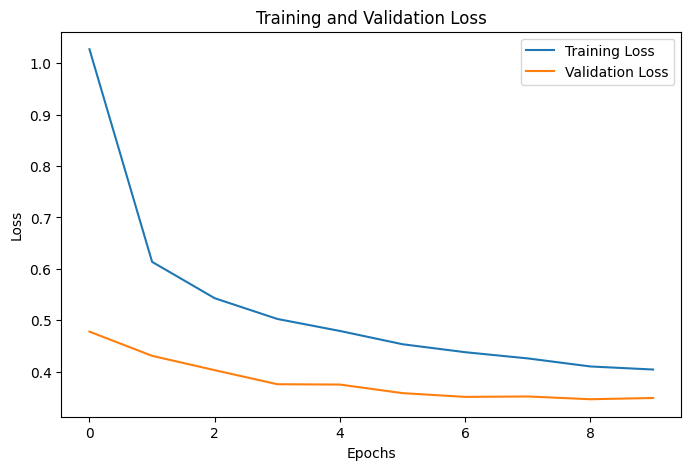

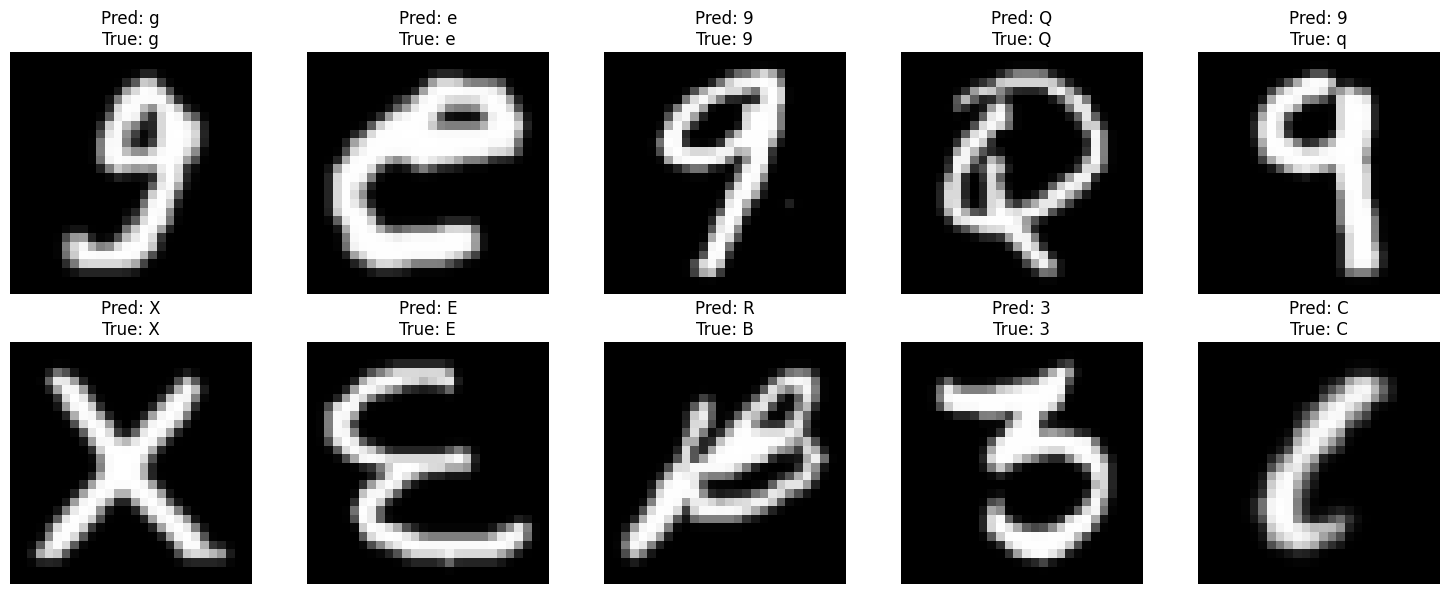

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

model.eval()
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()
preds = preds.cpu()
labels = labels.cpu()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(10):
    img = images[i].numpy().squeeze()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Pred: {emnist_mapping[preds[i].item()]}\nTrue: {emnist_mapping[labels[i].item()]}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()